**P2_8**

**Integrantes del grupo:**

- APONTE ZURITA WILLIAM ROMARIO
- VITERI AYALA FLAVIA KAMILA

## **<center>Ejercicio práctico semana 2</center>**

<b>Maestría</b>: Inteligencia Artificial Aplicada <br>
<b>Asignatura:</b> Procesamiento Acelerado de Lenguaje Natural <br>
<b>Profesor:</b> Edwin J. Rueda

**Bienvenidos** al ejercicio práctico de la segunda semana. A parte de las preguntas prácticas y teóricas que deberás responder, ten en cuenta lo siguiente:
- Encontrarás enlaces a documentación externa que te ayudará a resolver dudas.
- Resuelve los ejercicios de forma secuencial. Para que puedas ver el avance.
- La idea es guiarte sobre el proceso, por lo cual, encontrarás funciones pre-definidas.
    Por lo cual deberás colocar el código faltante dentro de las etiquetas especificadas.
- Encontrarás una salida esperada en cada celda para que tengas una guía. (Ten en cuenta que una vez ejecutada la celda, esta salida desaparecera).

### **Dataset**

Para este ejercicio práctico utilizaremos una fracción del dataset de MeLi. El dataset cuenta con 60k registros, los cuales hacen referencia al título de un producto y a su respectiva categoria. El objetivo del entregable es realizar un procesamiento del conjunto de datos con los métodos vistos en clase. Finalmente, veremos como se reduce la dimensionalidad y que tokens se vuelven más relevantes.

El dataset cuenta con la siguiente información:

    - title: Descripción del titúlo del producto
    - category: Categoria a la cual pertenece el producto

#### **Descargar y visualizar el conjunto de datos**

El conjunto de datos se encuentra público y puedes descargarlo [aquí](https://drive.google.com/file/d/1ivgFoL4HXwmc0u9n-rPR5c5U5lt5_Eds/view?usp=sharing). En este ejemplo, estará sobre la misma ruta donde se encuentra el notebook, por lo cual lo leemos con la función *read_csv* de [Pandas](https://pandas.pydata.org/docs/).

In [1]:
import pandas as pd
from time import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
url = "https://raw.githubusercontent.com/fkviteri/uide-maestria/main/04-procesamiento-acelerado-lenguaje-natural/filter_data.csv"

data = pd.read_csv(url, index_col=0)

data.head()

,title,category
0,Campera Ls2 Hombre Discovery Black Solo En Mg ...,MOTORCYCLE_JACKETS
1,Peine Beiyuan 13 Dientes,COMBS
2,Collar Arranque Fiat Palio Siena Strada Pin Fi...,IGNITION_SWITCH_ACTUATORS
3,Lampara Compatible Benq Ms517f Por Pedido,PROJECTOR_LAMPS
4,Canilla Doble Esférico Riego Prog Lavarropa Fv...,IRRIGATION_VALVES


##### **Normalización de los datos**

Para esta práctica, eliminaremos las stopwords, los signos de puntuación y llevaremos todas las palabras a minúsculas. Esto para disminuir la dimensionalidad del corpus y generar mejores representaciones vectoriales

In [3]:
import string
from nltk.corpus import stopwords

def normalization_sents(sentence):
    stop_words = stopwords.words("spanish")
    punc = string.punctuation
    make_trans = str.maketrans('','',punc)
    sentence = sentence.lower()
    sentence = sentence.translate(make_trans)
    new_sentence = [word for word in sentence.split() if word not in stop_words]
    return ' '.join(new_sentence)
    

def data_normalization(df):
    df = df.copy()
    df["title"] = df.title.apply(normalization_sents)
    return df

In [4]:
data_norm = data_normalization(data)
data_norm.head()

,title,category
0,campera ls2 hombre discovery black solo mg bikes,MOTORCYCLE_JACKETS
1,peine beiyuan 13 dientes,COMBS
2,collar arranque fiat palio siena strada pin fi...,IGNITION_SWITCH_ACTUATORS
3,lampara compatible benq ms517f pedido,PROJECTOR_LAMPS
4,canilla doble esférico riego prog lavarropa fv...,IRRIGATION_VALVES


##### Vamos a comparar las diferentes representaciones vectoriales
Para ello, vamos a medir las diferentes dimensiones generadas por los diferentes métodos de representación vectorial y al final del documento entrenaremos unos modelos para comparar su rendimiento:

#### **Ejercicio 1:**

Extraer en la variable corpus todos los tokens únicos. 

**Pregunta 1:** ¿Cuantos tokens hay?

**Nota**: Limitarse a extraer los tokens, no proceses mas el corpus

In [5]:
# Extraer todos los tokens de la columna title
corpus = []

for title in data_norm["title"]:
    corpus.extend(title.split())

# Extraer tokens únicos
vocab = set(corpus)

# Saber cuántos tokens únicos hay
print(f"Cantidad de tokens únicos: {len(vocab)}")

Cantidad de tokens únicos: 64901


#### **Ejercicio 2:**

Codifiquemos con one-hot encoding nuestro corpus. Crea un codificador de la clase *OneHotEncoder*. 

**Pregunta 2:** ¿Que dimensión tiene la matriz entrenada? <br>

**Nota**: mantendremos la matriz dispersa para no desperdiciar memoria

In [6]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Convertir vocabulario único a lista
vocab_list = list(vocab)

# Convertir a array columna
vocab_array = np.array(vocab_list).reshape(-1, 1)

# Crear codificador manteniendo matriz dispersa
encoder = OneHotEncoder()

# Entrenar y transformar
one_hot_matrix = encoder.fit_transform(vocab_array)

print("Dimensión del One-Hot Encoder entrenado:")
print(one_hot_matrix.shape)

Dimensión del One-Hot Encoder entrenado:
(64901, 64901)


#### **Ejericicio 3:**

Implementemos el método count vectorizer. 

**Pregunta 3:** ¿Cambia la dimensión de la matríz de salida? ¿Por qué?

**Nota**: Recuerde que el método *count vectorizer* recibe es las sentencias como entrada.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

# Crear vectorizador
count_vectorizer = CountVectorizer()

# Entrenar con sentencias
count_matrix = count_vectorizer.fit_transform(data_norm["title"])

# Dimensión
count_matrix.shape

print("Dimensión del One-Hot Encoder entrenado:")
print(count_matrix.shape)

Dimensión del One-Hot Encoder entrenado:
(60000, 64555)


**Respuesta pregunta 3:**

Sí, la dimensión de la matriz cambia respecto a One-Hot Encoding. En este caso, CountVectorizer generó una matriz de (60000, 64555).

Esto ocurre porque CountVectorizer trabaja a nivel de documentos completos, no de palabras individuales. Por ello, las filas representan los 60.000 títulos de productos del conjunto de datos y las columnas corresponden al vocabulario identificado en esos documentos. Cada valor dentro de la matriz indica cuántas veces aparece un término en un documento determinado.

A diferencia de One-Hot Encoding, que representaba palabras únicas de forma individual y por eso generaba una matriz cuadrada, CountVectorizer construye una representación documento-término, lo que resulta más útil para tareas de clasificación o análisis de texto.

#### **Ejercicio 4**

Implementemos la representación vectorial TF-IDF. 

**Pregunta 4:** ¿Cual es el tamaño de la matriz generada? ¿Se diferencia a las dos matrices generadas por los métodos *OneHotEncoder* y *CountVectorizer*?

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer()

# Entrenar con los títulos normalizados
tfidf_matrix = tfidf_vectorizer.fit_transform(data_norm["title"])

# Tamaño de la matriz
tfidf_matrix.shape

print("Matriz TF-IDF:")
print(count_matrix.shape)

Matriz TF-IDF:
(60000, 64555)


**Respuesta pregunta 4:**

La matriz generada con TF-IDF sí se diferencia de la obtenida con One-Hot Encoding, pero no de la generada con CountVectorizer en términos de dimensión. En este caso, TF-IDF produjo una matriz de (60000, 64555), igual que CountVectorizer, mientras que One-Hot Encoding generó una matriz de (64901, 64901).

Esto ocurre porque tanto CountVectorizer como TF-IDF trabajan con documentos completos, donde las filas representan los títulos y las columnas los términos del vocabulario. La diferencia entre ambos no está en el tamaño de la matriz, sino en sus valores: CountVectorizer almacena frecuencias de palabras, mientras que TF-IDF pondera la importancia de cada término dentro del corpus. En cambio, One-Hot Encoding representa palabras individuales, por lo que su estructura es distinta.

#### **Ejercicio 5:**
Implementemos el word2Vec pre-entrenado de fasttext. Para ello cargue el modelo y genere una función para retornar la sentencia mas parecida a la sentencia definida como entrada. Esta similitud debe ser calculada mediante la similitud del coseno. 

**Pregunta 5:** ¿Acaso pertenecen a la misma categoria las dos sentencias?

**Nota**: No se debe retornar la misma sentencia como la mas semejante

In [9]:
# Descargar vector de pesos
import urllib.request

url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz"
urllib.request.urlretrieve(url, "cc.es.300.vec.gz")

print("Descarga completada")

Descarga completada


In [10]:
# Descomprimir el vector
import gzip
import shutil

with gzip.open("cc.es.300.vec.gz", "rb") as f_in:
    with open("cc.es.300.vec", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Descompresión completada")

Descompresión completada


In [11]:
# Cargar modelo
from gensim.models import KeyedVectors

modelo_ft = KeyedVectors.load_word2vec_format(
    "cc.es.300.vec",
    binary=False
)

print("Modelo cargado correctamente")

Modelo cargado correctamente


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def sentence_to_vector(sentence, model):
    words = sentence.split()
    
    vectors = []
    for word in words:
        if word in model:
            vectors.append(model[word])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)


def get_most_similar(sentence, df, model):
    # vector de la sentencia de entrada
    sentence_vector = sentence_to_vector(sentence, model).reshape(1, -1)
    
    similarities = []
    
    for idx, row in df.iterrows():
        title = row["title"]
        
        # evitar retornar la misma sentencia
        if title == sentence:
            similarities.append(-1)
            continue
        
        # vector de cada sentencia del dataframe
        title_vector = sentence_to_vector(title, model).reshape(1, -1)
        
        # similitud coseno
        sim = cosine_similarity(sentence_vector, title_vector)[0][0]
        similarities.append(sim)
    
    # índice de la sentencia más similar
    most_simil_idx = np.argmax(similarities)
    most_similar_val = similarities[most_simil_idx]
    
    return (most_simil_idx, df.iloc[most_simil_idx].title, most_similar_val)

In [13]:
np.random.seed(32)
idx = np.random.choice(data_norm.index, 1)[0]
test_sent = data_norm.iloc[idx].title
print(f"sentence: {test_sent}")
result = get_most_similar(test_sent, data_norm, modelo_ft)

sentence: bolso alforja morral delantera bicicleta bike 2 botellas


In [14]:
print(f"sentencia a comparar: {test_sent} -> categoria: {data_norm.iloc[idx].category}")
print(f"sentencia mas parecida: {result[1]} -> categoría: {data_norm.iloc[result[0]].category}")
print(f"similitud del conseno: {result[2]}")

sentencia a comparar: bolso alforja morral delantera bicicleta bike 2 botellas -> categoria: BICYCLE_BAGS
sentencia mas parecida: mochila bolso morral cartera 3 1 cuero ecológico calidad -> categoría: HANDBAGS
similitud del conseno: 0.8282031416893005


#### **Ejercicio 6:**

Implementa una función que dada una sentencia/documento, retorne los $n$ documentos mas cercanos. Ten en cuenta que la métrica de similitud a usar es el coseno de la distancia. Se espera que la función retorne los indices de los $n$ documentos mas cercanos, los documentos y el valor de similitud de cada documento.

In [15]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def get_n_most_similar(sentence, df, model, n=5):
    # vector de la sentencia de entrada
    sentence_vector = sentence_to_vector(sentence, model).reshape(1, -1)
    
    results = []
    
    for idx, row in df.iterrows():
        title = row["title"]
        
        # evitar retornar la misma sentencia
        if title == sentence:
            continue
        
        # vector del documento
        title_vector = sentence_to_vector(title, model).reshape(1, -1)
        
        # similitud coseno
        sim = cosine_similarity(sentence_vector, title_vector)[0][0]
        
        results.append((idx, title, sim))
    
    # ordenar de mayor a menor similitud
    results = sorted(results, key=lambda x: x[2], reverse=True)
    
    # retornar los n más similares
    return results[:n]

# Prueba
sentence = data_norm.iloc[0].title

resultados = get_n_most_similar(
    sentence,
    data_norm,
    modelo_ft,
    n=5
)

# Print resultados
pd.DataFrame(
    resultados,
    columns=["indice", "documento", "similitud"]
)

,indice,documento,similitud
0,22889,juego billetera portadocumentos mg,0.883670
1,18503,manubrio neken motocross fat 286 mm blanc fran...,0.873330
2,33610,pelota voley penalty mg 3600 original,0.864150
3,32999,campanas frenos ford transit rodado 15 mg,0.862254
4,58870,pantalon nine to one cordura xena ls2 dama muj...,0.848030


#### **Pregunta 6:** ¿Qué podemos concluir de los métodos de representación vectorial vistos?

A lo largo del ejercicio fue posible comparar distintos métodos de representación vectorial de texto, observando una evolución desde enfoques simples hasta modelos con mayor capacidad semántica.

El One-Hot Encoding representa cada palabra como un vector único, pero genera matrices muy dispersas y no captura relaciones entre términos, ya que palabras similares son tratadas como completamente independientes. CountVectorizer mejora este enfoque al trabajar con documentos completos y registrar la frecuencia de las palabras, aunque sigue sin comprender significado ni contexto, además de ignorar el orden de los términos.

Por su parte, TF-IDF representa una mejora sobre CountVectorizer al ponderar la importancia de cada palabra dentro del corpus, reduciendo el peso de términos demasiado comunes y destacando palabras más relevantes. Aunque mantiene una estructura similar a CountVectorizer, ofrece una representación más informativa para tareas de clasificación o recuperación de información.

Finalmente, los métodos basados en embeddings, como Word2Vec y FastText, ofrecen una representación mucho más rica, ya que generan vectores densos donde palabras semánticamente similares se ubican cerca entre sí. En particular, FastText añade robustez al trabajar con subpalabras, lo que mejora el manejo de términos desconocidos. En conclusión, mientras los métodos tradicionales son útiles para representar texto de forma básica, los embeddings permiten una comprensión más cercana al significado real del lenguaje.

#### **Ejercicio 7:**

Define un método de clasificación basado en los *embeddings* para detectar la clase a la que pertence un titulo de producto.

**Nota:** se podria utilizar una técnica sencilla como basarse en la etiqueta de los $k$ vecinos mas cercanos.

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import numpy as np
import pandas as pd

def classify_by_embeddings(sentence, df, model, k=5, label_col="category"):
    # vectorizar la sentencia nueva
    sentence_vector = sentence_to_vector(sentence, model).reshape(1, -1)
    
    results = []
    
    for idx, row in df.iterrows():
        title = row["title"]
        label = row[label_col]
        
        title_vector = sentence_to_vector(title, model).reshape(1, -1)
        
        sim = cosine_similarity(sentence_vector, title_vector)[0][0]
        
        results.append((idx, title, label, sim))
    
    # ordenar por mayor similitud
    results = sorted(results, key=lambda x: x[3], reverse=True)
    
    # tomar los k vecinos más cercanos
    k_neighbors = results[:k]
    
    # extraer etiquetas de los vecinos
    labels = [neighbor[2] for neighbor in k_neighbors]
    
    # clase más frecuente
    predicted_class = Counter(labels).most_common(1)[0][0]
    
    return predicted_class, k_neighbors

# Imprimir

sentence = data_norm.iloc[0].title

predicted_class, neighbors = classify_by_embeddings(
    sentence,
    data_norm,
    modelo_ft,
    k=5,
    label_col="category"   # cambia si tu columna tiene otro nombre
)

print("TÍTULO CONSULTADO:")
print(sentence)

print("\nCLASE PREDICHA:")
print(predicted_class)

neighbors_df = pd.DataFrame(
    neighbors,
    columns=["Índice", "Título similar", "Clase", "Similitud"]
)

neighbors_df

TÍTULO CONSULTADO:
campera ls2 hombre discovery black solo mg bikes

CLASE PREDICHA:
MOTORCYCLE_JACKETS


,Índice,Título similar,Clase,Similitud
0,0,campera ls2 hombre discovery black solo mg bikes,MOTORCYCLE_JACKETS,1.000000
1,22889,juego billetera portadocumentos mg,TRAVEL_DOCUMENT_ORGANIZERS,0.883670
2,18503,manubrio neken motocross fat 286 mm blanc fran...,MOTORCYCLE_HANDLEBARS,0.873330
3,33610,pelota voley penalty mg 3600 original,VOLLEYBALL_BALLS,0.864150
4,32999,campanas frenos ford transit rodado 15 mg,BRAKE_DRUMS,0.862254


### **Ítem extra:** Visualización top 5 documentos más similares

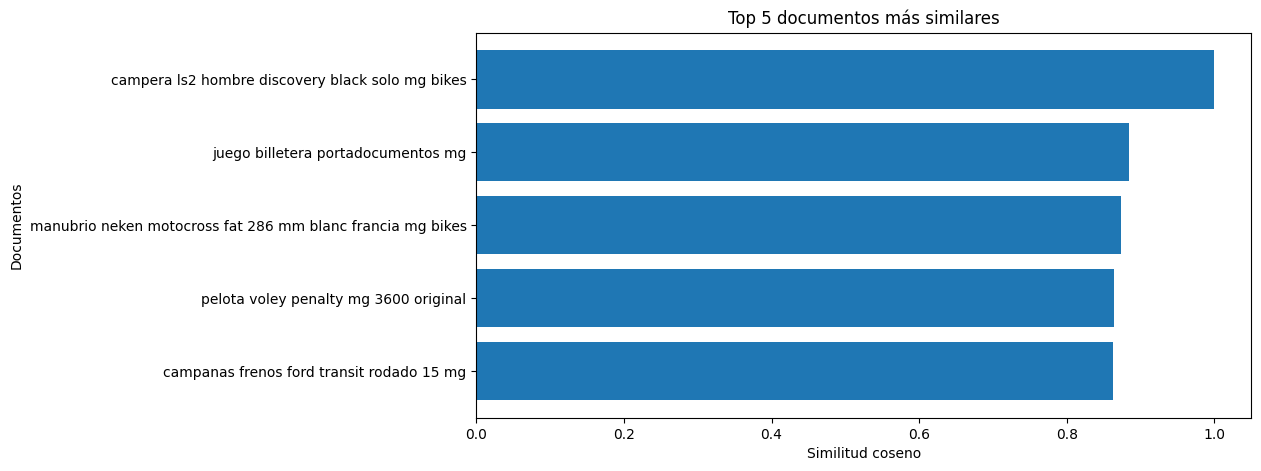

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.barh(
    neighbors_df["Título similar"],
    neighbors_df["Similitud"]
)

plt.xlabel("Similitud coseno")
plt.ylabel("Documentos")
plt.title("Top 5 documentos más similares")

plt.gca().invert_yaxis()
plt.show()

### **Ítem extra:** Visualización vecinos más cercanos en espacio de embbedings

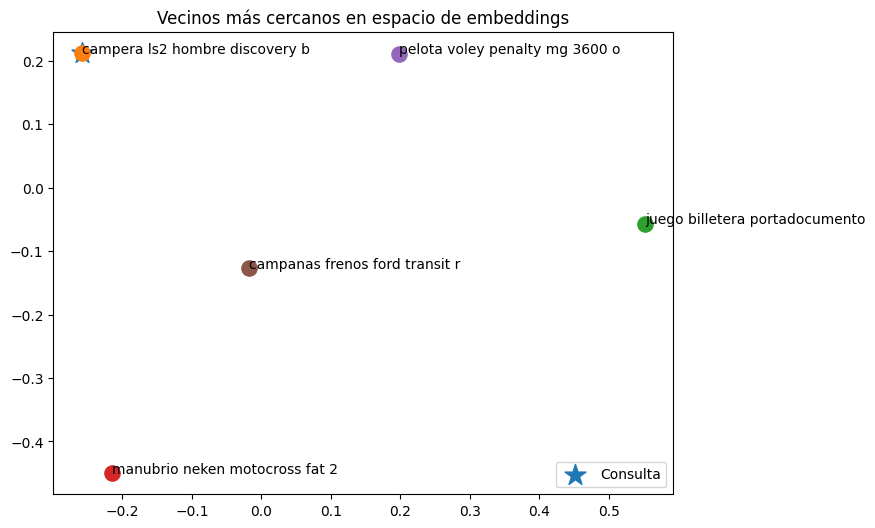

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

sentence = data_norm.iloc[0].title

predicted_class, neighbors = classify_by_embeddings(
    sentence,
    data_norm,
    modelo_ft,
    k=5,
    label_col="category"
)

# vector consulta
query_vector = sentence_to_vector(sentence, modelo_ft)

# vectores vecinos
neighbor_vectors = []
neighbor_labels = []
neighbor_titles = []

for idx, title, label, sim in neighbors:
    neighbor_vectors.append(sentence_to_vector(title, modelo_ft))
    neighbor_labels.append(label)
    neighbor_titles.append(title[:30])

# combinar
all_vectors = np.vstack([query_vector] + neighbor_vectors)

# reducir dimensión
pca = PCA(n_components=2)
coords = pca.fit_transform(all_vectors)

plt.figure(figsize=(8,6))

# punto consulta
plt.scatter(coords[0,0], coords[0,1], s=250, marker="*", label="Consulta")

# vecinos
for i in range(1, len(coords)):
    plt.scatter(coords[i,0], coords[i,1], s=120)
    plt.text(coords[i,0], coords[i,1], neighbor_titles[i-1])

plt.title("Vecinos más cercanos en espacio de embeddings")
plt.legend()
plt.show()

### **Pregunta 8:**

##### ¿Cómo podrías emplear lo visto en tu ámbito profesional? ¿Consideras útil implementar solo esta parte, o crees que se debería complementar con otras técnicas de NLP?


**APONTE ZURITA WILLIAM ROMARIO**

**VITERI AYALA FLAVIA KAMILA**

En mi ámbito profesional, particularmente en el trabajo que realizo en CAF con evaluaciones ex post y automatización de informes mediante inteligencia artificial, considero que estas técnicas tienen una aplicación bastante clara. Por ejemplo, métodos como TF-IDF o los embeddings podrían utilizarse para identificar similitud entre proyectos, documentos o secciones de informes, lo que facilitaría tareas como recuperación de evidencia documental, comparación con evaluaciones históricas o incluso la identificación automática de lecciones aprendidas similares entre operaciones.

En el caso de los embeddings, veo un potencial mayor, ya que permiten trabajar con similitud semántica y no únicamente con coincidencia de palabras. Esto sería útil, por ejemplo, para encontrar documentos técnicamente relacionados aunque utilicen terminología distinta, algo frecuente en informes de proyectos de diferentes países o sectores. También podría apoyar procesos como clasificación automática de documentos, agrupación temática o fortalecimiento de sistemas tipo RAG para alimentar modelos generativos con evidencia relevante.

Sin embargo, considero que implementar únicamente estas técnicas sería insuficiente. Aunque son útiles para representar texto y medir similitud, en contextos como evaluación ex post se requiere una comprensión más profunda del contenido, incluyendo extracción de entidades, análisis contextual, clasificación supervisada e incluso modelos generativos con validación sobre documentos fuente. Por ello, lo más adecuado sería complementar estas técnicas con otras herramientas de NLP y modelos más avanzados, de forma que el proceso no solo identifique similitudes textuales, sino que también interprete correctamente el contenido y lo conecte con criterios metodológicos de evaluación.

In [19]:
import os
import gc

# eliminar variable del modelo de RAM
del modelo_ft

# forzar liberación de memoria
gc.collect()

# eliminar archivos del disco
if os.path.exists("cc.es.300.vec.gz"):
    os.remove("cc.es.300.vec.gz")

if os.path.exists("cc.es.300.vec"):
    os.remove("cc.es.300.vec")

print("Memoria y archivos liberados")

Memoria y archivos liberados
